In [ ]:
import numpy as np
import pandas as pd
from snowflake_info import df
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option('display.max_columns', 200)
df = df.head(1000)
df = df.drop(columns='DATE')


x = df.drop(columns='PRICE')
y = df['PRICE'].astype(float)

x_train, x_test, y_train, y_test =train_test_split(x , y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

Y_after_prediction = model.predict(x_test)

error_df = x_test.copy()
error_df['actual_value'] = y_test
error_df['predicted_value'] = Y_after_prediction.round(2)

error_df['residual'] = error_df['actual_value'] - error_df['predicted_value']
error_df['absolute_error'] = np.abs(error_df['residual'])


print(error_df[['actual_value', 'predicted_value', 'residual', 'absolute_error']].head())


     actual_value  predicted_value  residual  absolute_error
521      582000.0        622645.63 -40645.63        40645.63
737      607500.0        564172.10  43327.90        43327.90
740      310000.0        405701.06 -95701.06        95701.06
660      700000.0        693153.56   6846.44         6846.44
411     1051000.0       1068090.49 -17090.49        17090.49


In [72]:
# 1. Sort the DataFrame by Absolute Error in descending order
error_df_sorted = error_df.sort_values(by='absolute_error', ascending=False)

# 2. Define what "worst" means (e.g., the top 5% of errors)
top_5_percent_threshold = int(len(error_df_sorted) * 0.05)

# 3. Create a new DataFrame with just the worst offenders
worst_offenders = error_df_sorted.head(top_5_percent_threshold)

print(f"Total rows in test set: {len(error_df)}")
print(f"Analyzing the top {len(worst_offenders)} worst predictions.")
print(worst_offenders[['actual_value', 'predicted_value', 'residual', 'absolute_error']].head())

Total rows in test set: 200
Analyzing the top 10 worst predictions.
     actual_value  predicted_value    residual  absolute_error
265     3200000.0       1628364.88  1571635.12      1571635.12
462     2238890.0       1307045.08   931844.92       931844.92
617     2555000.0       1910322.99   644677.01       644677.01
370     1750000.0       1118472.97   631527.03       631527.03
371     1500000.0        918852.49   581147.51       581147.51


In [73]:
# Example A: Are the biggest mistakes happening for high-value targets?
print("Average actual value for whole dataset:", error_df['actual_value'].mean())
print("Average actual value for worst offenders:", worst_offenders['actual_value'].mean())

# Example B: Look at summary statistics for the worst offenders to see if any feature stands out
print(worst_offenders.describe())

# Example C: If you have a categorical column (like 'City'), see if one city dominates the errors
# (Assuming you have a column named 'City' in your original X_test)
# if 'City' in worst_offenders.columns:
#     print(worst_offenders['City'].value_counts(normalize=True))

Average actual value for whole dataset: 577834.26
Average actual value for worst offenders: 1641589.0
        BEDROOMS  BATHROOMS  SQFT_LIVING       SQFT_LOT  WATERFRONT  \
count  10.000000  10.000000    10.000000      10.000000   10.000000   
mean    4.500000   3.800000  4254.500000   28284.700000    0.100000   
std     1.269296   1.398412  1515.927384   39396.485123    0.316228   
min     3.000000   2.000000  2430.000000    3997.000000    0.000000   
25%     4.000000   3.000000  3422.500000    8157.000000    0.000000   
50%     4.000000   3.500000  3520.000000   11763.000000    0.000000   
75%     5.000000   4.000000  5005.000000   23699.250000    0.000000   
max     7.000000   7.000000  7270.000000  130017.000000    1.000000   

            VIEW  CONDITION      GRADE   SQFT_ABOVE  SQFT_BASEMENT  \
count  10.000000  10.000000  10.000000    10.000000       10.00000   
mean    0.800000   3.500000   8.400000  3552.500000      702.00000   
std     1.032796   0.971825   2.065591  1432.444

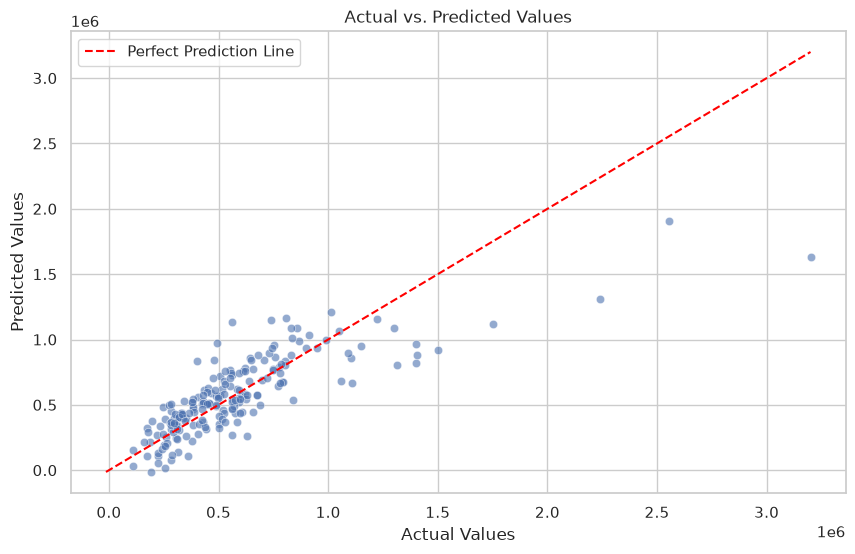

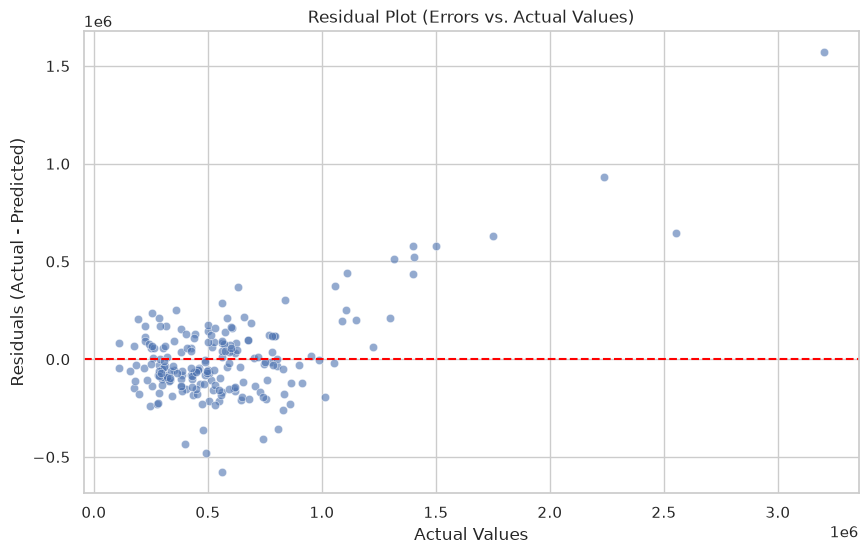

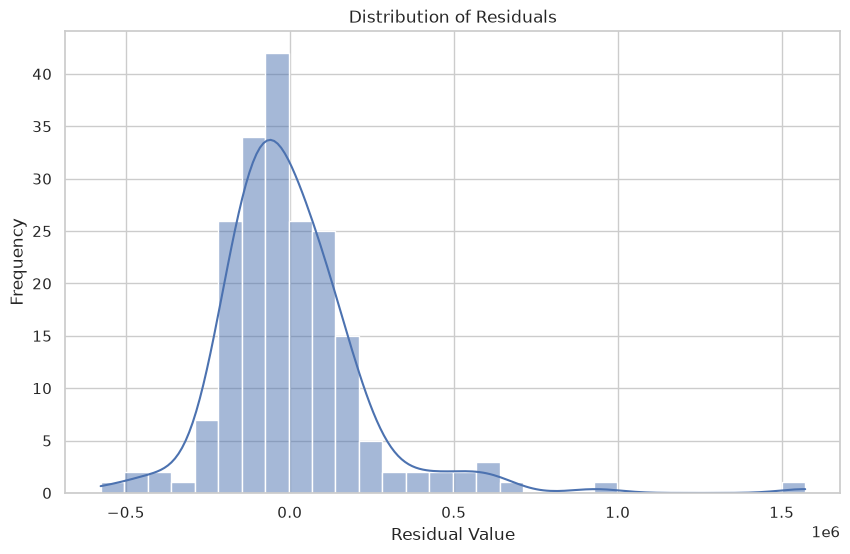

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

# --- Plot 1: Actual vs. Predicted ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='actual_value', y='predicted_value', data=error_df, alpha=0.6)

# Draw a perfect prediction diagonal line
min_val = min(error_df['actual_value'].min(), error_df['predicted_value'].min())
max_val = max(error_df['actual_value'].max(), error_df['predicted_value'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()


# --- Plot 2: Residual Plot ---
# This shows if errors get bigger as the actual value gets bigger
plt.figure(figsize=(10, 6))
sns.scatterplot(x='actual_value', y='residual', data=error_df, alpha=0.6)

# Draw a horizontal line at 0 (where error is zero)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residual Plot (Errors vs. Actual Values)')
plt.xlabel('Actual Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# --- Plot 3: Distribution of Errors ---
# This checks if your errors are normally distributed (a bell curve), 
# which is an assumption of some models like Linear Regression.
plt.figure(figsize=(10, 6))
sns.histplot(error_df['residual'], kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()